# Predict using some model and time series data as input 

- Recipe 2-1. Moving Average (MA) Forecast 
- Recipe 2-2. Autoregressive (AR) Model 
- Recipe 2-3. Autoregressive Moving Average (ARMA) Model 
- Recipe 2-4. Autoregressive Integrated Moving Average (ARIMA) Model 
- Recipe 2-5. Grid search Hyperparameter Tuning for Autoregressive Integrated Moving Average (ARIMA) Model
- Recipe 2-6. Seasonal Autoregressive Integrated Moving Average (SARIMA) Model 
- Recipe 2-7. Simple Exponential Smoothing (SES) Model 
- Recipe 2-8. Holt-Winters (HW) Model

##  Setup & Data Preparation
Trước khi train các mô hình thống kê học đơn biến (Statistical Univariate Models), chúng ta cần load dữ liệu Bitcoin, xử lý đồng nhất tần suất (Daily) và chia tập **Train/Test**. 

Đa số các mô hình thống kê trong Python sử dụng thư viện **`statsmodels`** và nhận đầu vào trực tiếp là Pandas Series thay vì PyTorch DataLoader.

Loading and concatenating both hourly datasets...


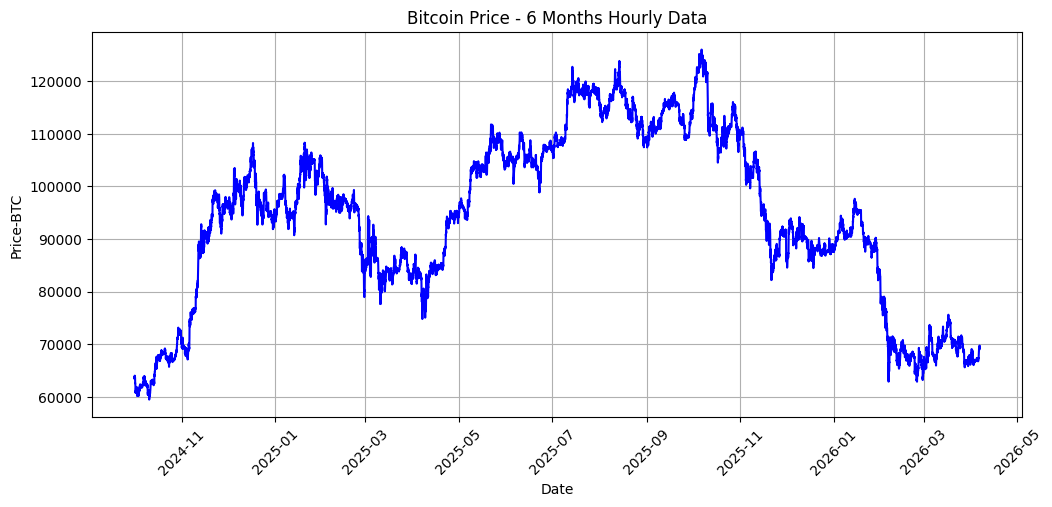

Train data shape: (10609, 1)
Test data shape: (2653, 1)


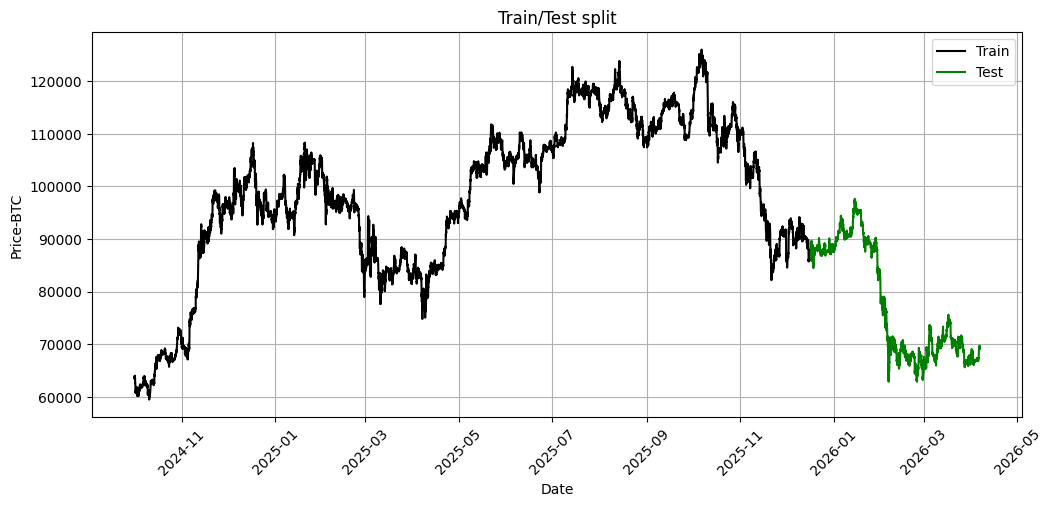

In [66]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import itertools
import warnings

# Tắt cảnh báo
warnings.filterwarnings("ignore")

# ====== STEP 3-2 & 3-3: LOAD VÀ PREPROCESS DATA ======
print("Loading and concatenating both hourly datasets...")
df1 = pd.read_csv("../Data/btc_6months_1h.csv", parse_dates=True, index_col=0)
df2 = pd.read_csv("../Data/btc_1h_from_2024_10_01.csv", parse_dates=True, index_col=0)

# Nối 2 tập dữ liệu, loại bỏ giá trị trùng lặp theo thời gian (nếu có) và sắp xếp lại
hourly_btc = pd.concat([df1, df2])
hourly_btc = hourly_btc[~hourly_btc.index.duplicated(keep='last')].sort_index()

if 'Close' in hourly_btc.columns:
    df_hourly = hourly_btc[['Close']].copy()
    df_hourly.rename(columns={'Close': 'BTC-USD'}, inplace=True)
elif 'BTC-USD' in hourly_btc.columns:
    df_hourly = hourly_btc[['BTC-USD']].copy()

# Đảm bảo index là kiểu datetime
df_hourly.index = pd.to_datetime(df_hourly.index)

# ====== STEP 3-4: PLOT THE TIME SERIES ======
plt.figure(figsize=(12, 5))
plt.plot(df_hourly.index, df_hourly['BTC-USD'], color='blue')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title('Bitcoin Price - 6 Months Hourly Data')
plt.grid(True)
plt.show()

# ====== STEP 3-5: TRAIN-TEST SPLIT ======
# Dùng 80% train, 20% test
split_idx = int(len(df_hourly) * 0.8)
train_data = df_hourly.iloc[:split_idx]
test_data = df_hourly.iloc[split_idx:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# ====== STEP 3-6: PLOT TRAIN-TEST SPLIT ======
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['BTC-USD'], color="black", label='Train')
plt.plot(test_data.index, test_data['BTC-USD'], color="green", label='Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split")
plt.legend()
plt.grid(True)
plt.show()

# Biến lưu trữ Actuals cho train
actuals = train_data['BTC-USD']
test_actuals = test_data['BTC-USD']

In [67]:
# Hàm tiện ích dùng chung để Plot và In RMSE/MAE
def plot_and_evaluate(model_name, predictions_series, actuals_series):
    plt.figure(figsize=(15, 6))
    
    # Zoom In: Lấy 200 mẫu test cuối cùng của Train để hình không bị nén quá
    zoom_train = train_data.iloc[-200:]
    
    plt.plot(zoom_train.index, zoom_train['BTC-USD'], color="black", label='Train (last 200h)')
    plt.plot(actuals_series.index, actuals_series, color="green", label='Test (Actual)')
    plt.plot(predictions_series.index, predictions_series, color="red", linestyle="--", label=f'{model_name} Rolling', marker='x')
    
    plt.ylabel('Price-BTC')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.title(f"{model_name} Rolling Forecast (T+1) vs Actuals")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    rmse = np.sqrt(mean_squared_error(actuals_series.values, predictions_series.values))
    mae = mean_absolute_error(actuals_series.values, predictions_series.values)
    print(f"--- {model_name} ROLLING EVALUATION ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE: {mae:,.2f}\n")
    
    return rmse, mae

results_dict = {}

# ==== HÀM THỰC THI ROLLING FORECAST ====
# Chạy Rolling tốn CPU (vì phải Fit lại hàng trăm lần), ta giới hạn số bước test
TEST_STEPS = 50 # BẠN CÓ THỂ ĐỔI THÀNH len(test_data) nếu có đủ thời gian và CPU mạnh!
print(f"Sẽ chạy Rolling Forecast cho {TEST_STEPS} bước (giờ) tương lai...")
actuals_subset = test_actuals.iloc[:TEST_STEPS]

def do_rolling_arima(order, seasonal_order=None):
    history = list(actuals.values)
    test_values = test_actuals.values[:TEST_STEPS]
    preds = []
    for t in range(TEST_STEPS):
        if seasonal_order:
            mod = SARIMAX(history, order=order, seasonal_order=seasonal_order)
            fit_mod = mod.fit(disp=False, maxiter=20)
        else:
            mod = ARIMA(history, order=order)
            fit_mod = mod.fit()
        preds.append(fit_mod.forecast()[0])
        history.append(test_values[t])
        if (t+1) % 10 == 0: print(f"  Đã trượt {t+1}/{TEST_STEPS} bước...")
    
    return pd.Series(preds, index=test_actuals.index[:TEST_STEPS])

def do_rolling_exp(model_type='ses', seasonal_periods=24):
    history = list(actuals.values)
    test_values = test_actuals.values[:TEST_STEPS]
    preds = []
    for t in range(TEST_STEPS):
        if model_type == 'ses':
            mod = SimpleExpSmoothing(history)
        else:
            mod = ExponentialSmoothing(history, trend='add', seasonal='add', seasonal_periods=seasonal_periods)
        fit_mod = mod.fit()
        preds.append(fit_mod.forecast()[0])
        history.append(test_values[t])
        if (t+1) % 10 == 0: print(f"  Đã trượt {t+1}/{TEST_STEPS} bước...")
    
    return pd.Series(preds, index=test_actuals.index[:TEST_STEPS])

Sẽ chạy Rolling Forecast cho 50 bước (giờ) tương lai...



=== Recipe 2-1. Moving Average (MA) ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


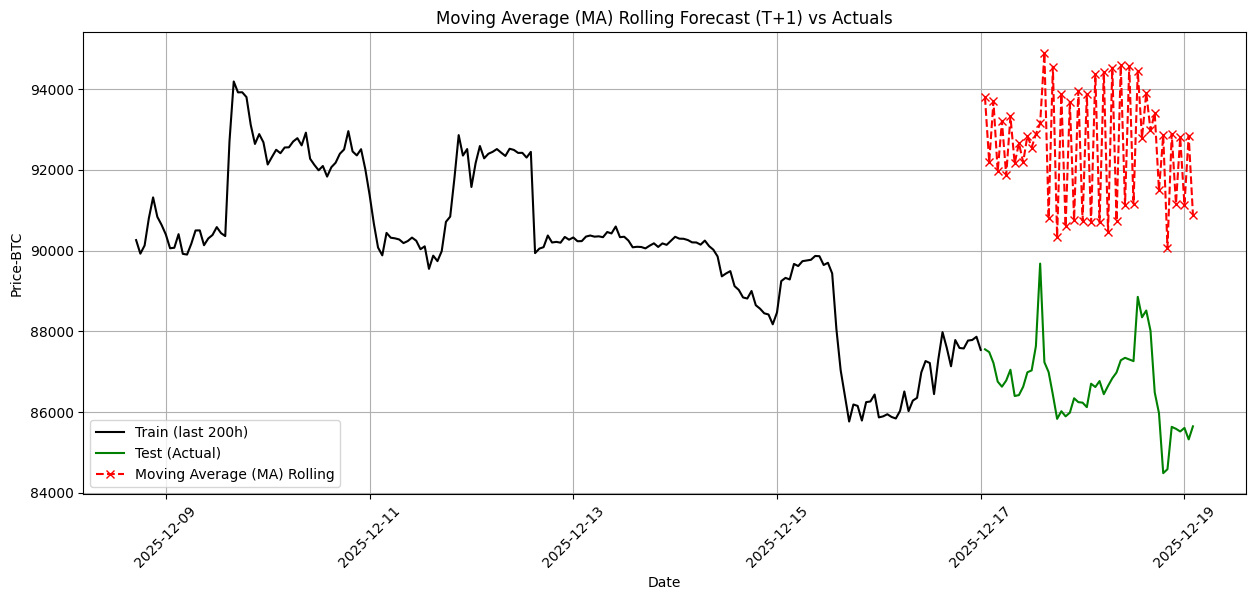

--- Moving Average (MA) ROLLING EVALUATION ---
RMSE: 6,035.98
MAE: 5,865.41


=== Recipe 2-2. Autoregressive (AR) ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


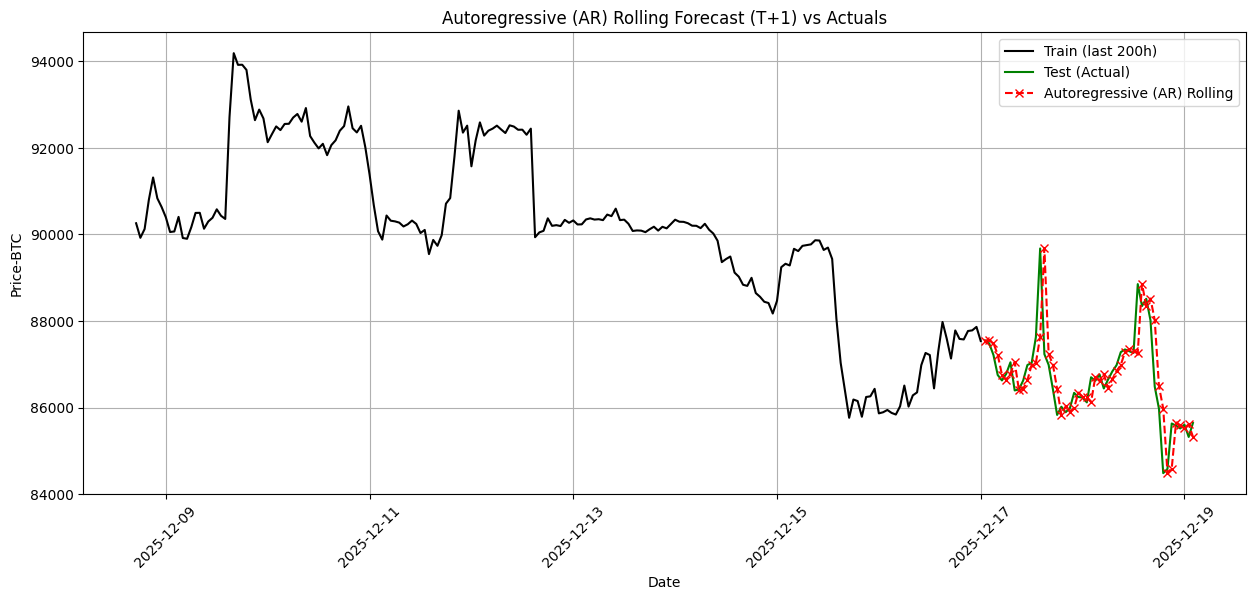

--- Autoregressive (AR) ROLLING EVALUATION ---
RMSE: 668.11
MAE: 409.71


=== Recipe 2-3. ARMA Model ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


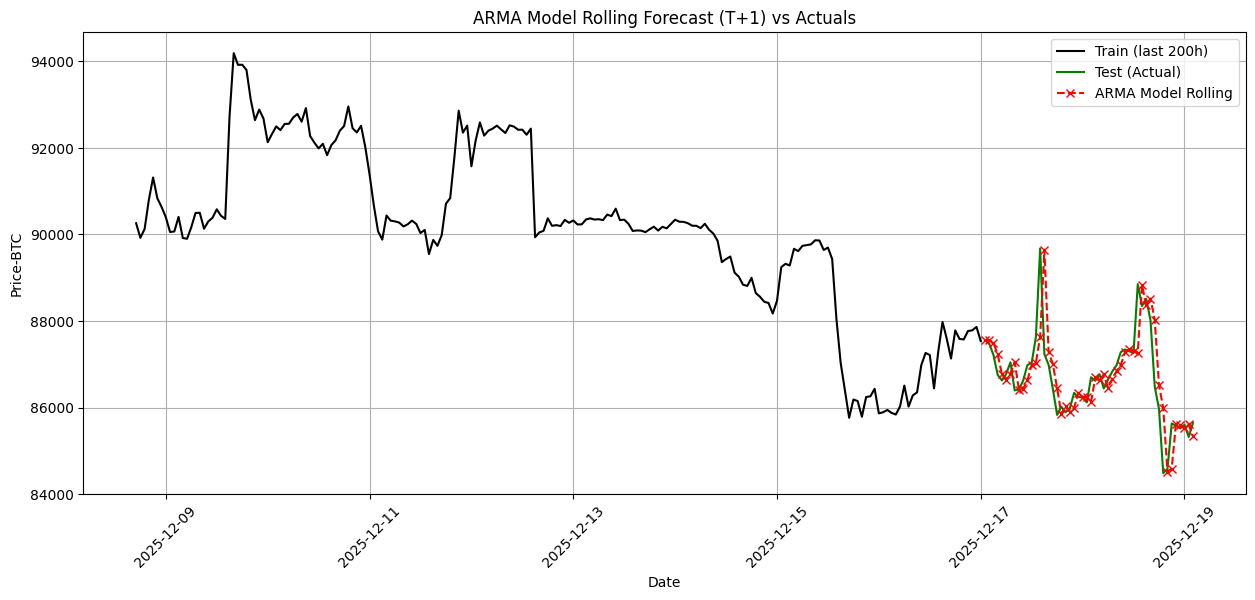

--- ARMA Model ROLLING EVALUATION ---
RMSE: 667.63
MAE: 409.04



In [68]:
# Recipe 2-1. Moving Average (MA) Forecast (ARIMA(0,0,1))
print("\n=== Recipe 2-1. Moving Average (MA) ===")
predictions_ma = do_rolling_arima(order=(0, 0, 1))
results_dict['MA'] = plot_and_evaluate("Moving Average (MA)", predictions_ma, actuals_subset)

# Recipe 2-2. Autoregressive (AR) Model (ARIMA(1,0,0))
print("\n=== Recipe 2-2. Autoregressive (AR) ===")
predictions_ar = do_rolling_arima(order=(1, 0, 0))
results_dict['AR'] = plot_and_evaluate("Autoregressive (AR)", predictions_ar, actuals_subset)

# Recipe 2-3. Autoregressive Moving Average (ARMA) Model (ARIMA(1,0,1))
print("\n=== Recipe 2-3. ARMA Model ===")
predictions_arma = do_rolling_arima(order=(1, 0, 1))
results_dict['ARMA'] = plot_and_evaluate("ARMA Model", predictions_arma, actuals_subset)


=== Recipe 2-4. ARIMA ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


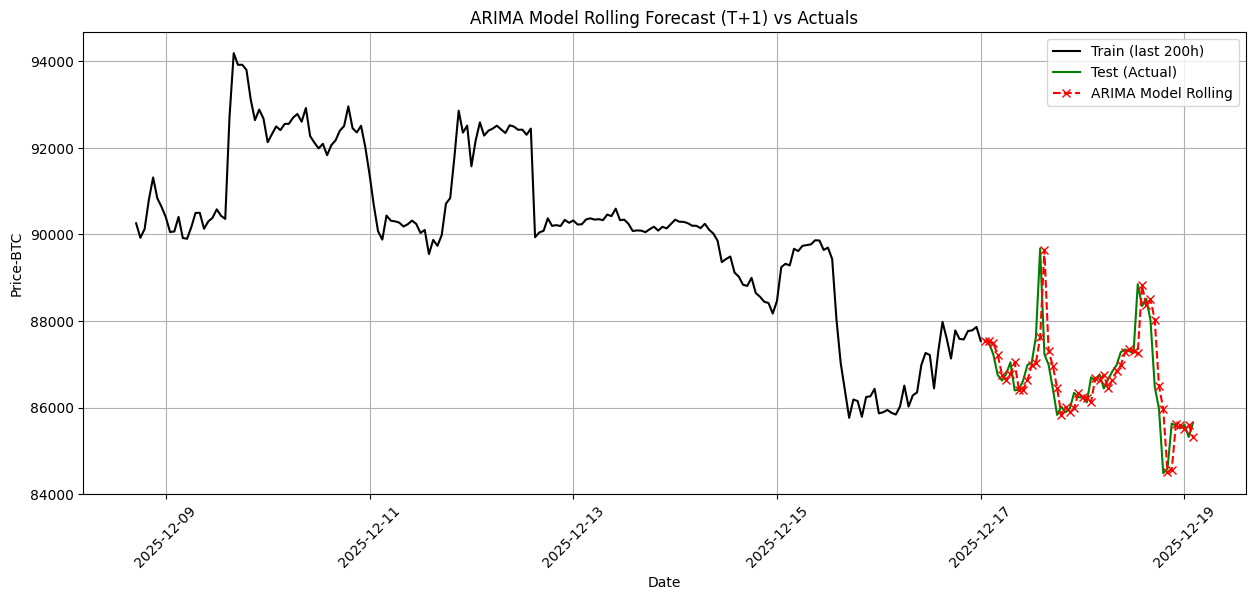

--- ARIMA Model ROLLING EVALUATION ---
RMSE: 667.79
MAE: 409.21


=== Recipe 2-5. Grid Search Tuning ===
Best ARIMA param found: (1, 1, 1)
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


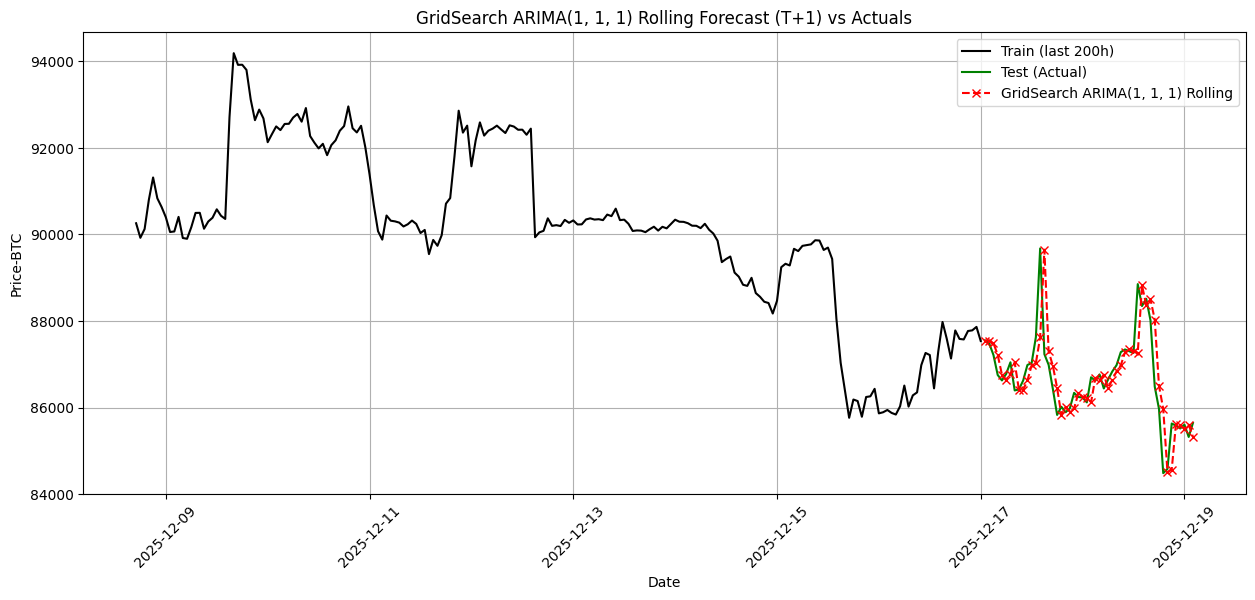

--- GridSearch ARIMA(1, 1, 1) ROLLING EVALUATION ---
RMSE: 667.79
MAE: 409.21



In [69]:
# Recipe 2-4. ARIMA Model 
print("\n=== Recipe 2-4. ARIMA ===")
predictions_arima = do_rolling_arima(order=(1, 1, 1))
results_dict['ARIMA'] = plot_and_evaluate("ARIMA Model", predictions_arima, actuals_subset)

# Recipe 2-5. Grid search Hyperparameter Tuning for ARIMA
print("\n=== Recipe 2-5. Grid Search Tuning ===")
import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_pdq = None

# Tìm tham số tốt nhất bằng cách Fit 1 lần trên toàn bộ tập lượng Train
for param in pdq:
    try:
        mod = ARIMA(actuals.values, order=param)
        results = mod.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
    except:
        continue

print(f"Best ARIMA param found: {best_pdq}")

# Áp dụng tham số tìm được vào hàm Rolling trượt từng bước test
predictions_best_arima = do_rolling_arima(order=best_pdq)
results_dict['ARIMA (GridSearch)'] = plot_and_evaluate(f"GridSearch ARIMA{best_pdq}", predictions_best_arima, actuals_subset)


=== Recipe 2-6. SARIMA ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


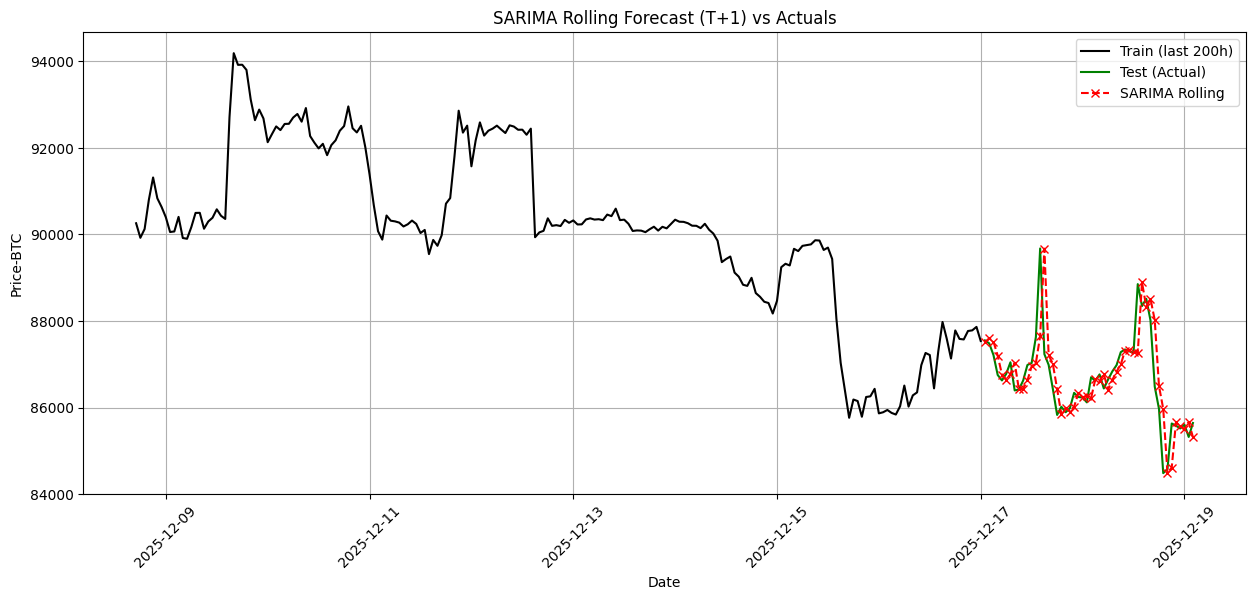

--- SARIMA ROLLING EVALUATION ---
RMSE: 665.85
MAE: 408.91


=== Recipe 2-7. Simple Exponential Smoothing ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


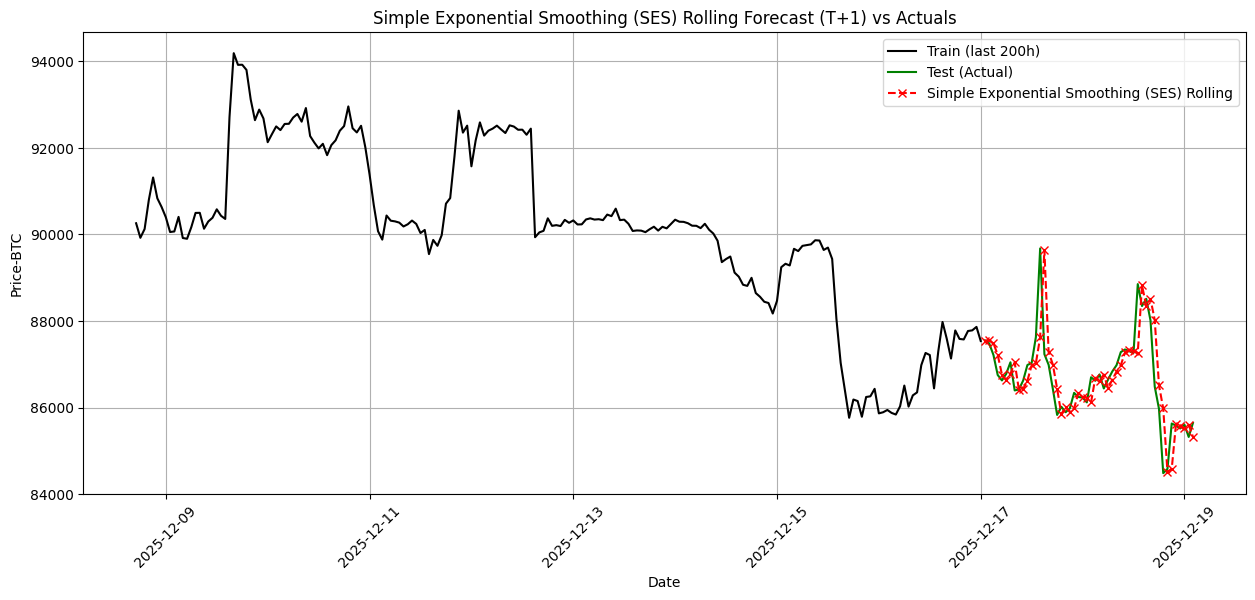

--- Simple Exponential Smoothing (SES) ROLLING EVALUATION ---
RMSE: 667.26
MAE: 409.17


=== Recipe 2-8. Holt-Winters (HW) ===
  Đã trượt 10/50 bước...
  Đã trượt 20/50 bước...
  Đã trượt 30/50 bước...
  Đã trượt 40/50 bước...
  Đã trượt 50/50 bước...


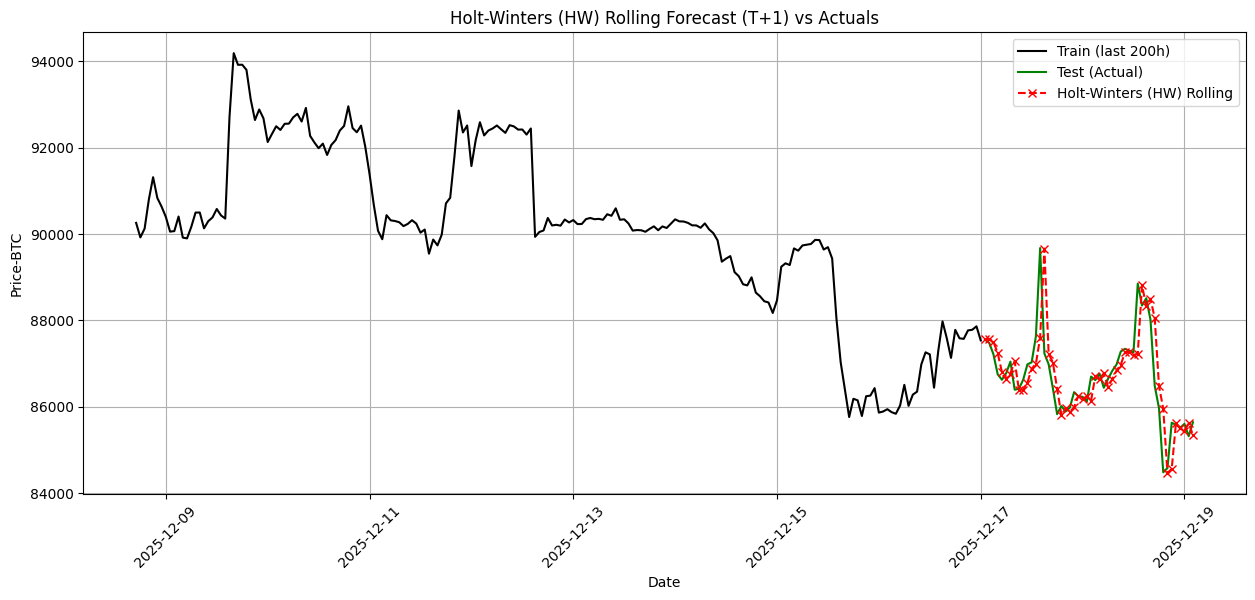

--- Holt-Winters (HW) ROLLING EVALUATION ---
RMSE: 674.06
MAE: 417.15



In [70]:
# Recipe 2-6. Seasonal Autoregressive Integrated Moving Average (SARIMA)
print("\n=== Recipe 2-6. SARIMA ===")
predictions_sarima = do_rolling_arima(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results_dict['SARIMA'] = plot_and_evaluate("SARIMA", predictions_sarima, actuals_subset)

# Recipe 2-7. Simple Exponential Smoothing (SES) Model 
print("\n=== Recipe 2-7. Simple Exponential Smoothing ===")
predictions_ses = do_rolling_exp(model_type='ses')
results_dict['SES'] = plot_and_evaluate("Simple Exponential Smoothing (SES)", predictions_ses, actuals_subset)

# Recipe 2-8. Holt-Winters (HW) Model
print("\n=== Recipe 2-8. Holt-Winters (HW) ===")
predictions_hw = do_rolling_exp(model_type='hw', seasonal_periods=24)
results_dict['Holt-Winters'] = plot_and_evaluate("Holt-Winters (HW)", predictions_hw, actuals_subset)

In [71]:
# === Bảng Tổng Kết Toàn Bộ RMSE, MAE của 8 Mô Hình ===
import pandas as pd

comparison_df = pd.DataFrame.from_dict(
    results_dict, 
    orient='index', 
    columns=['RMSE', 'MAE']
).sort_values(by='RMSE', ascending=True)

print("\n==== BẢNG XẾP HẠNG ROOT-MEAN-SQUARE-ERROR CÁC MÔ HÌNH ====\n")
print(comparison_df.to_string(float_format="{:,.2f}".format))


==== BẢNG XẾP HẠNG ROOT-MEAN-SQUARE-ERROR CÁC MÔ HÌNH ====

                       RMSE      MAE
SARIMA               665.85   408.91
SES                  667.26   409.17
ARMA                 667.63   409.04
ARIMA                667.79   409.21
ARIMA (GridSearch)   667.79   409.21
AR                   668.11   409.71
Holt-Winters         674.06   417.15
MA                 6,035.98 5,865.41
